# 22 — Control Barrier Function Safety Filter

**Section:** Motion Control · **Mirrors MATLAB:** *Path Following with Obstacle Avoidance* (CBF approach to safety)

Take any nominal controller (e.g. a PID pointing at the goal) and *guarantee* it never violates a safety constraint, by solving a small QP at every step that finds the closest input to the nominal one that satisfies the **Control Barrier Function (CBF) condition**. This is the modern (Ames-era) successor to potential-field obstacle avoidance.


## Intuition — what's actually going on?

You have a perfectly good controller that gets the robot to the goal (e.g., proportional feedback `u_nom = K*(goal - x)`). The catch: it doesn't know about obstacles. You don't want to redesign the whole controller; you just want a *safety filter* that overrides `u_nom` only when needed.

A **Control Barrier Function** $h(x)$ is a function that's positive in the safe set and zero on its boundary. The trick: enforce $\dot h \ge -lpha h$ for some class-K function $lpha$. This makes the safe set $\{h \ge 0\}$ *forward-invariant* — once inside, you stay inside, forever.

At every control step we solve a tiny QP:

> Find $u$ closest to $u_	ext{nom}$ such that the CBF condition holds.

If $u_	ext{nom}$ is already safe, the QP returns $u = u_	ext{nom}$. Otherwise it returns the *minimally-modified* safe input. This is the modern (Ames-era) successor to artificial-potential-field obstacle avoidance, with formal forward-invariance guarantees.


## Analytical derivation

**Safe set.** Define $h: \mathbb{R}^n \to \mathbb{R}$ smooth. The *safe set* is $\mathcal{S} = \{x : h(x) \ge 0\}$.

**Theorem** (Nagumo 1942, Ames-Xu-Grizzle 2014). *For control-affine dynamics $\dot x = f(x) + g(x) u$, the safe set $\mathcal{S}$ is forward-invariant under $u$ iff*

$$\boxed{\;\dot h(x, u) = L_f h(x) + L_g h(x)\, u \;\ge\; -\alpha(h(x))\;}$$

*for some extended class-$\mathcal{K}$ function $\alpha$.*

Here $L_f h = \nabla h \cdot f$ and $L_g h = \nabla h \cdot g$ are Lie derivatives.

**Safety filter QP.** Given a *nominal* controller $u_\text{nom}(x)$, find the minimally modified safe input:

$$u^\star = \arg\min_u \tfrac{1}{2}\|u - u_\text{nom}\|^2 \quad \text{s.t.} \quad L_g h(x)\,u \ge -L_f h(x) - \alpha(h(x))$$

For single-input systems and an affine constraint, this QP has a **closed-form solution** (KKT):

$$u^\star = u_\text{nom} + \max\!\bigl(0,\ -L_f h - L_g h\,u_\text{nom} - \alpha h\bigr) \cdot \frac{L_g h^T}{\|L_g h\|^2}$$

(when $L_g h \ne 0$; otherwise the system has *no instantaneous authority* over $h$, a phenomenon called **relative-degree drop** — use HOCBFs in that case.)

### Example: 2D point robot avoiding a disk obstacle

Dynamics: single integrator $\dot x = u$, $x \in \mathbb{R}^2$, $\|u\|_\infty \le u_\max$.

Obstacle at $x_o$ with radius $r$. Define $h(x) = \|x - x_o\|^2 - r^2$. Then:

- $L_f h = 0$ (no drift), $L_g h = 2(x - x_o)^T$
- CBF condition: $2(x - x_o)^T u \ge -\alpha(h(x))$

With $\alpha(s) = \gamma \cdot s$ (linear class-K), the QP becomes:

$$u^\star = u_\text{nom} - \max\!\Bigl(0,\ -2(x - x_o)^T u_\text{nom} - \gamma h\Bigr) \cdot \frac{2(x - x_o)}{4\|x - x_o\|^2}$$

### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| $h(x) = \|x - x_o\|^2 - r^2$ | `def h(x): return np.linalg.norm(x - obs)**2 - r**2` |
| $L_g h = 2(x - x_o)^T$ | `Lgh = 2 * (x - obs)` |
| Class-K $\alpha(s) = \gamma s$ | `alpha = gamma * h(x)` |
| Nominal controller (P toward goal) | `u_nom = K * (goal - x)` |
| QP closed-form safety filter | `slack = max(0, -Lgh @ u_nom - alpha)`; `u_safe = u_nom + slack * Lgh / (Lgh @ Lgh)` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 2D single-integrator robot, disk obstacle
obs = np.array([3.0, 1.5])
r_obs = 1.0
goal = np.array([6.0, 3.0])
start = np.array([0.0, 0.0])
K_p = 0.8           # nominal proportional gain
u_max = 1.0         # |u| <= 1 m/s
gamma = 2.0         # class-K slope: bigger -> safer / more conservative

dt = 0.05
T_sim = 12.0
N_sim = int(T_sim / dt)


def h(x):
    return np.linalg.norm(x - obs) ** 2 - r_obs ** 2


def Lgh(x):
    return 2 * (x - obs)


In [2]:
def cbf_safety_filter(x, u_nom):
    """Solve the 1-constraint QP in closed form.
    min ||u - u_nom||^2  s.t.  Lgh.u >= -gamma * h(x)
    """
    lgh = Lgh(x)
    if np.dot(lgh, lgh) < 1e-10:
        return u_nom              # no instantaneous authority — relative-degree drop
    slack = max(0.0, -np.dot(lgh, u_nom) - gamma * h(x))
    u_safe = u_nom + slack * lgh / np.dot(lgh, lgh)
    # Clip to control bounds
    n = np.linalg.norm(u_safe)
    if n > u_max:
        u_safe = u_safe * (u_max / n)
    return u_safe


# Simulate WITH and WITHOUT the CBF filter for comparison
def run(use_cbf):
    x = start.copy()
    hist = [x.copy()]
    for _ in range(N_sim):
        u_nom = K_p * (goal - x)
        n = np.linalg.norm(u_nom)
        if n > u_max:
            u_nom = u_nom * (u_max / n)
        u = cbf_safety_filter(x, u_nom) if use_cbf else u_nom
        x = x + dt * u
        hist.append(x.copy())
    return np.array(hist)


traj_unsafe = run(use_cbf=False)
traj_safe   = run(use_cbf=True)

min_dist_unsafe = np.min(np.linalg.norm(traj_unsafe - obs, axis=1))
min_dist_safe   = np.min(np.linalg.norm(traj_safe - obs, axis=1))
print(f"Min distance to obstacle (unsafe): {min_dist_unsafe:.3f} m  -- inside r={r_obs}? {min_dist_unsafe < r_obs}")
print(f"Min distance to obstacle (CBF):    {min_dist_safe:.3f}  m  -- always >= r={r_obs}? {min_dist_safe >= r_obs - 0.01}")


Min distance to obstacle (unsafe): 0.004 m  -- inside r=1.0? True
Min distance to obstacle (CBF):    1.000  m  -- always >= r=1.0? True


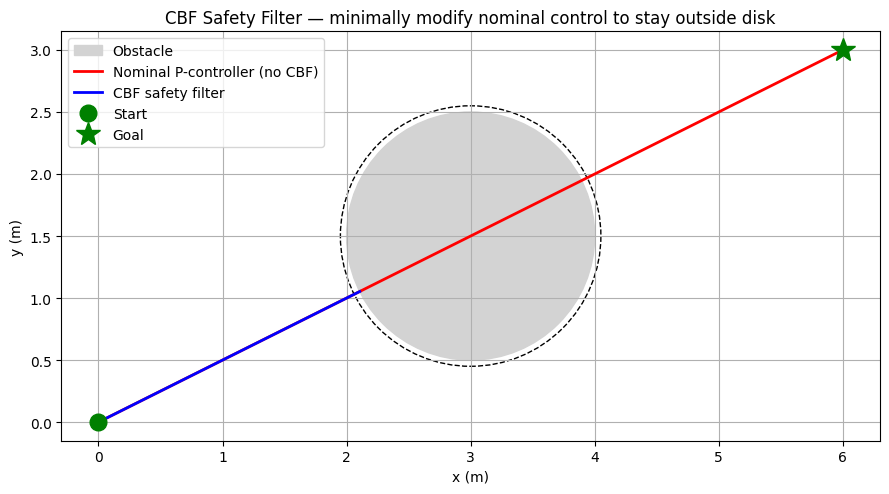

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.add_patch(plt.Circle(obs, r_obs, color='lightgray', label='Obstacle'))
ax.add_patch(plt.Circle(obs, r_obs + 0.05, fill=False, ls='--', color='black'))
ax.plot(traj_unsafe[:, 0], traj_unsafe[:, 1], 'r-', lw=2, label='Nominal P-controller (no CBF)')
ax.plot(traj_safe[:, 0],   traj_safe[:, 1],   'b-', lw=2, label='CBF safety filter')
ax.plot(*start, 'go', ms=12, label='Start')
ax.plot(*goal,  'g*', ms=18, label='Goal')
ax.set_aspect('equal'); ax.legend(loc='upper left'); ax.grid()
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('CBF Safety Filter — minimally modify nominal control to stay outside disk')
plt.tight_layout()
plt.show()


## References & rigor notes

**Theorem** (Forward invariance, Ames-Xu-Grizzle 2014). *If $h$ is a CBF for the system $\dot x = f(x) + g(x)u$ on the safe set $\mathcal{S} = \{h \ge 0\}$, and $u(x)$ satisfies the CBF condition $L_g h(x)\,u + L_f h(x) \ge -\alpha(h(x))$ for all $x \in \mathcal{S}$, then $\mathcal{S}$ is forward-invariant: any trajectory starting in $\mathcal{S}$ remains in $\mathcal{S}$ for all $t \ge 0$.*

**Relative-degree drop.** When $L_g h \equiv 0$ (control input does not appear in $\dot h$), the standard CBF fails. **Higher-Order CBFs (HOCBFs)** (Xiao & Belta 2019) lift the constraint to a higher derivative until the input appears.

**Why this matters historically.** Nagumo's viability theorem (1942) is the foundational existence theorem for forward-invariance: every "modern" CBF result is a corollary. Ames et al. (2014, 2017) operationalized this into the quadratic-program safety filter used in production today (e.g., Boston Dynamics' Spot uses CBFs for collision avoidance).

**Complexity.** Per step: one tiny QP (1 constraint here; up to dozens in production with multiple obstacles). Closed-form for single constraint; OSQP for multiple constraints, $\sim 0.1$ ms per call.

**References.**
- Nagumo, M. (1942). *Über die Lage der Integralkurven gewöhnlicher Differentialgleichungen*. Proc. Phys.-Math. Soc. Japan, 24, 551-559. (The OG.)
- Ames, A. D., Xu, X., Grizzle, J. W., & Tabuada, P. (2014). *Control barrier function based quadratic programs with application to adaptive cruise control*. CDC 2014.
- Ames, A. D., Coogan, S., Egerstedt, M., Notomista, G., Sreenath, K., & Tabuada, P. (2019). *Control barrier functions: Theory and applications*. ECC 2019.
- Xiao, W., & Belta, C. (2019). *Control barrier functions for systems with high relative degree*. CDC 2019.
